In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('loan_approval_data.csv')

In [3]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# handel missing values

In [4]:
num_val =df.select_dtypes(include=['number']).columns
categorical_val = df.select_dtypes(include=["object"]).columns

In [5]:
from sklearn.impute import SimpleImputer
num_val_impute = SimpleImputer(strategy = 'mean')
cat_val_impute = SimpleImputer(strategy = 'most_frequent')
df[num_val] = num_val_impute.fit_transform(df[num_val])
df[categorical_val] = cat_val_impute.fit_transform(df[categorical_val])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

# EDA

([<matplotlib.patches.Wedge at 0x1e2df832cf0>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'Yes'),
  Text(0.6521428261765839, -0.8858384357581341, 'No')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

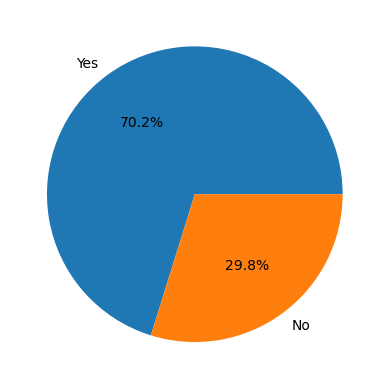

In [7]:
classes_count = df['Loan_Approved'].value_counts()
plt.pie(classes_count , labels = ['Yes' , 'No'] , autopct = '%1.1f%%')

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

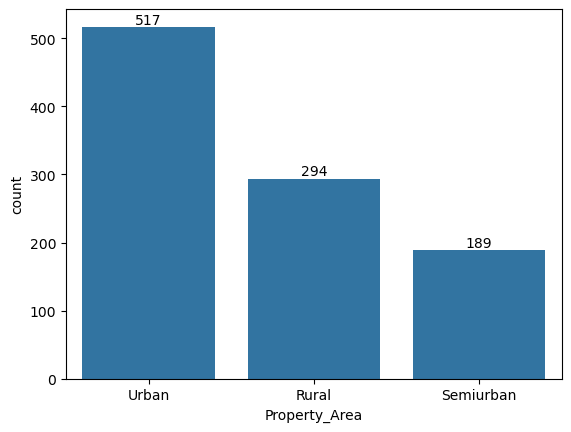

In [8]:
#analyze categories
classes_count = df['Property_Area'].value_counts()
ax = sns.barplot(classes_count )
ax.bar_label(ax.containers[0] )

# Feture Engineering

In [9]:
df = df.drop('Applicant_ID' , axis = 1)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [10]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
ohe_col = ['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area','Gender', 'Employer_Category']
ohe = OneHotEncoder(drop='first' , sparse_output=False , handle_unknown= 'ignore')
Encoded = ohe.fit_transform(df[ohe_col])
Encoded_df = pd.DataFrame(Encoded  , columns= ohe.get_feature_names_out(ohe_col) , index = df.index)
le = LabelEncoder()
df['Education_Level'] = le.fit_transform(df['Education_Level'])
df['Loan_Approved'] = le.fit_transform(df['Loan_Approved'])
df = df.drop(ohe_col , axis = 1)
df = pd.concat([df,Encoded_df] , axis = 1)

In [11]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


<Axes: >

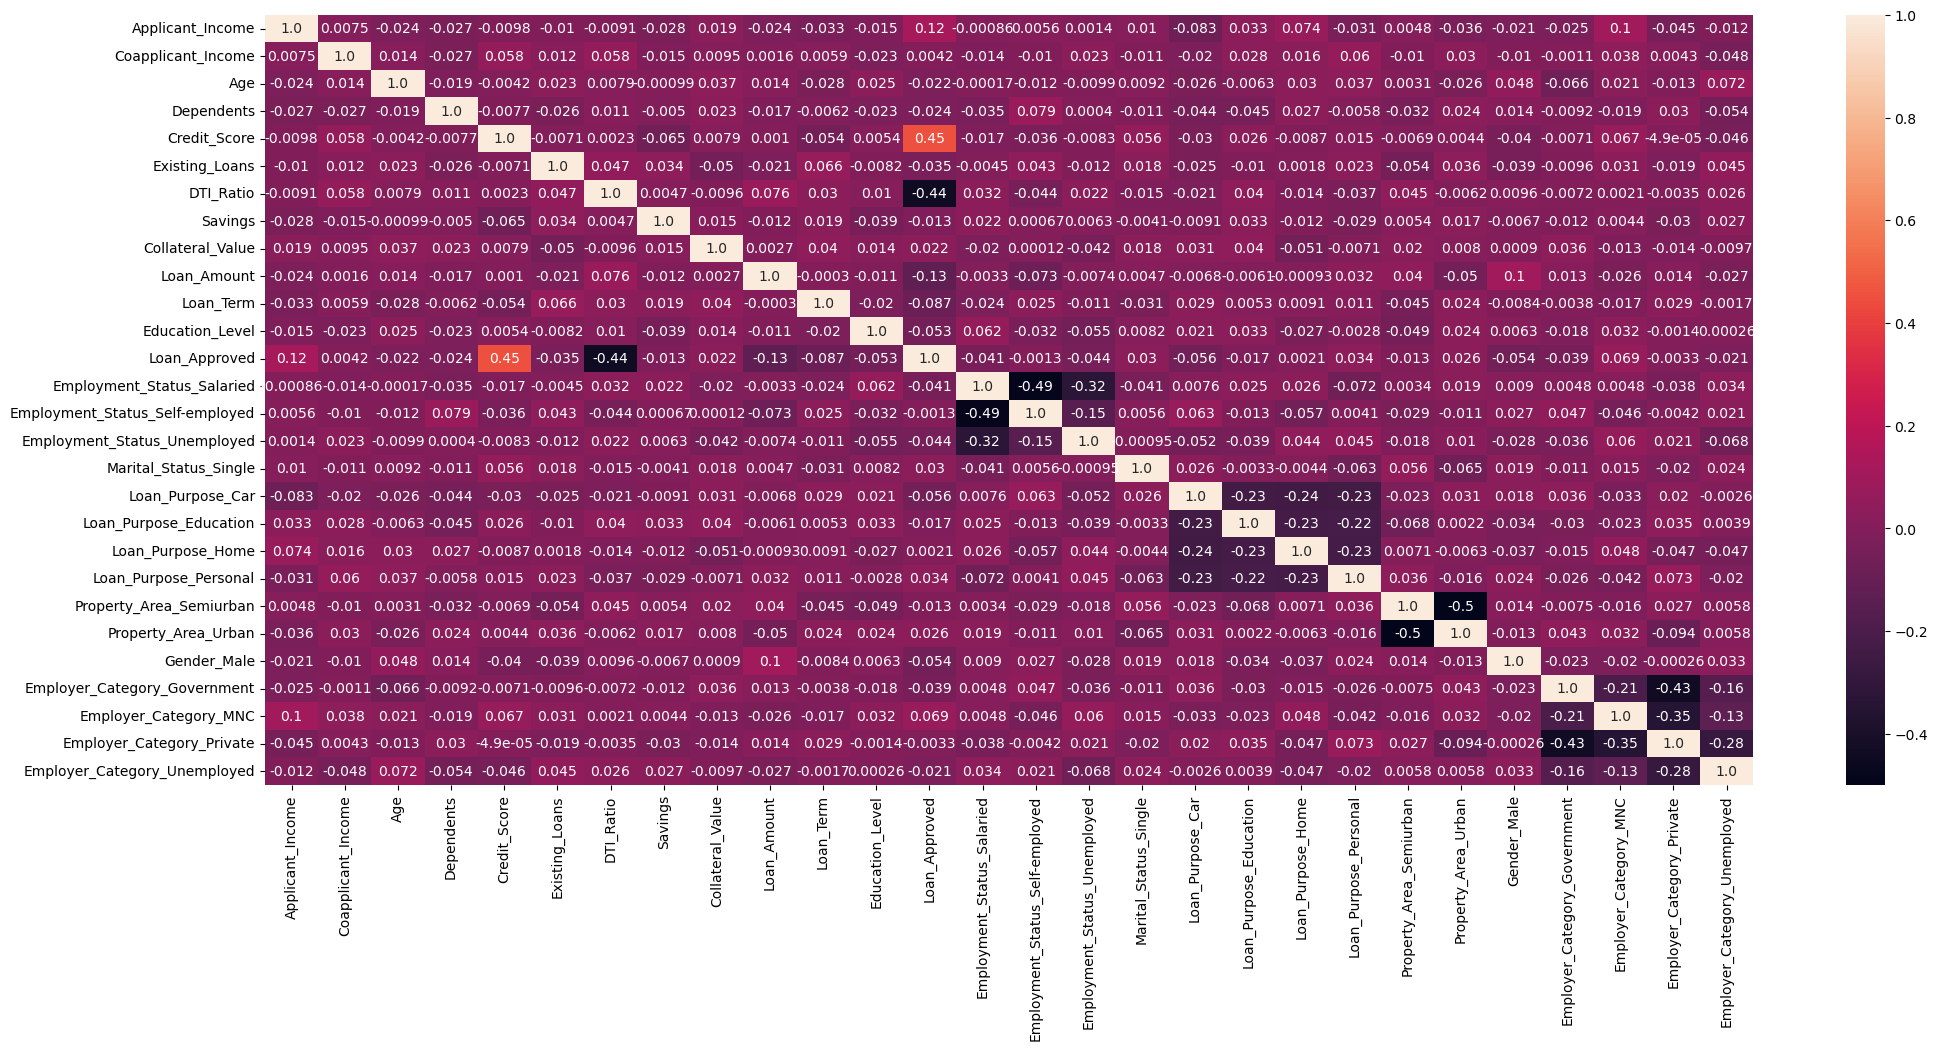

In [12]:
# Corelation Heatmap
num_cols = df.select_dtypes(include='number')
corr_mat = num_cols.corr()
plt.figure(figsize = (24,10))
sns.heatmap(corr_mat , annot=True , fmt = '0.2')

# Train_test split and feature scaling

In [13]:
X = df.drop('Loan_Approved', axis = 1)
Y = df['Loan_Approved']
x_train , x_test , y_train , y_test = train_test_split(X, Y , test_size = 0.2 ,random_state= 42)

In [14]:
# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

# model selection and training

In [15]:
# Logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train_scaled , y_train)

LogisticRegression()

In [16]:
#knn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
classifier = KNeighborsClassifier()
param_grid = {'n_neighbors':[3,5,7,9,11]}

clasifier_cv = GridSearchCV(
    classifier,
    param_grid,
    cv = 5,
    scoring = 'precision'
)
clasifier_cv.fit(x_train_scaled , y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11]}, scoring='precision')

In [17]:
# Naive Bays
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train_scaled , y_train)


GaussianNB()

In [18]:
from sklearn.metrics import accuracy_score , precision_score , confusion_matrix , f1_score ,recall_score
models = {
    'lr':lr,
    'knn':clasifier_cv ,
    'gnb':gnb
}
for name , model in models.items():
    print("Evaluation for " , name )
    Y_pred = model.predict(x_test_scaled )
    print("accuracy score is : ",accuracy_score(y_test , Y_pred))
    print("recall score is : ",recall_score(y_test , Y_pred))
    print("Precision score : " , precision_score(y_test , Y_pred))
    print("F1 score : ",f1_score(y_test , Y_pred))
    print("confusion matrix",confusion_matrix(y_test , Y_pred))
    print()

Evaluation for  lr
accuracy score is :  0.885
recall score is :  0.7540983606557377
Precision score :  0.8518518518518519
F1 score :  0.8
confusion matrix [[131   8]
 [ 15  46]]

Evaluation for  knn
accuracy score is :  0.75
recall score is :  0.39344262295081966
Precision score :  0.6486486486486487
F1 score :  0.4897959183673469
confusion matrix [[126  13]
 [ 37  24]]

Evaluation for  gnb
accuracy score is :  0.845
recall score is :  0.6885245901639344
Precision score :  0.7777777777777778
F1 score :  0.7304347826086957
confusion matrix [[127  12]
 [ 19  42]]



In [19]:
# Hence logistic regression has best precision score 

# Feature engineering

In [20]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [21]:
df['Credit_Score_sq'] = df['Credit_Score'] **2
df['DTI_Ratio_sq'] = df['DTI_Ratio'] **2
X = df.drop(['Credit_Score','DTI_Ratio' , 'Loan_Approved'] , axis =1)
Y = df['Loan_Approved']

In [24]:
x_train , x_test , y_train , y_test = train_test_split(X, Y , test_size = 0.2 ,random_state= 42)
# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)
# Logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train_scaled , y_train)
#knn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
classifier = KNeighborsClassifier()
param_grid = {'n_neighbors':[3,5,7,9,11]}

clasifier_cv = GridSearchCV(
    classifier,
    param_grid,
    cv = 5,
    scoring = 'precision'
)
clasifier_cv.fit(x_train_scaled , y_train)
# Naive Bays
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train_scaled , y_train)
#Evaluation
from sklearn.metrics import accuracy_score , precision_score , confusion_matrix , f1_score ,recall_score
models = {
    'lr':lr,
    'knn':clasifier_cv ,
    'gnb':gnb
}
for name , model in models.items():
    print("Evaluation for " , name )
    Y_pred = model.predict(x_test_scaled )
    print("accuracy score is : ",accuracy_score(y_test , Y_pred))
    print("recall score is : ",recall_score(y_test , Y_pred))
    print("Precision score : " , precision_score(y_test , Y_pred))
    print("F1 score : ",f1_score(y_test , Y_pred))
    print("confusion matrix",confusion_matrix(y_test , Y_pred))
    print()

Evaluation for  lr
accuracy score is :  0.87
recall score is :  0.7377049180327869
Precision score :  0.8181818181818182
F1 score :  0.7758620689655172
confusion matrix [[129  10]
 [ 16  45]]

Evaluation for  knn
accuracy score is :  0.74
recall score is :  0.39344262295081966
Precision score :  0.6153846153846154
F1 score :  0.48
confusion matrix [[124  15]
 [ 37  24]]

Evaluation for  gnb
accuracy score is :  0.86
recall score is :  0.7377049180327869
Precision score :  0.7894736842105263
F1 score :  0.7627118644067796
confusion matrix [[127  12]
 [ 16  45]]

